# Point Cloud Processing: Pemisahan Lantai dan Dinding

Segmentasi bidang dari data LiDAR sintetis menggunakan dua metode:
1. **RANSAC iteratif** — plane fitting berbasis konsensus geometrik
2. **Region Growing** — pertumbuhan wilayah berbasis kesamaan arah normal permukaan

| Komponen | Bidang | Label |
|---|---|---|
| Lantai | z = 0 (horizontal) | 0 |
| Dinding A | x = 0 (vertikal) | 1 |
| Dinding B | y = W (vertikal, ⊥ Dinding A) | 2 |

## 1. Generasi Data Point Cloud

Membangkitkan data sintetis yang merepresentasikan sudut ruangan:
- **Lantai** (label 0): bidang horizontal z ≈ 0, noise Gaussian σ=0.03 pada sumbu-z
- **Dinding A** (label 1): bidang vertikal x ≈ 0, noise Gaussian σ=0.03 pada sumbu-x
- **Dinding B** (label 2): bidang vertikal y ≈ W, noise Gaussian σ=0.03 pada sumbu-y

Dinding A dan Dinding B saling tegak lurus.

In [16]:
# !pip install open3d scikit-learn matplotlib  # uncomment jika belum terinstal

import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
import time

SEED = 42
np.random.seed(SEED)

LABEL_COLORS = {
    0:  '#1f77b4',  # lantai    → biru
    1:  '#ff7f0e',  # dinding A → oranye
    2:  '#2ca02c',  # dinding B → hijau
    -1: '#aaaaaa',  # unclassified → abu
}
LABEL_NAMES = {0: 'Lantai', 1: 'Dinding A', 2: 'Dinding B', -1: 'Unclassified'}

# Parameter dimensi ruangan
L = 10.0   # panjang (sumbu-x), meter
W = 8.0    # lebar   (sumbu-y), meter
H = 3.0    # tinggi  (sumbu-z), meter

# Jumlah titik
n_floor = 10000
n_wall  = 3000

print(f"NumPy  : {np.__version__}")
print(f"Open3D : {o3d.__version__}")

print(f"Total titik  : {n_floor+n_wall*2}")
print(f"Lantai       : {n_floor}")
print(f"Dinding A    : {n_wall}")
print(f"Dinding B    : {n_wall}")

NumPy  : 2.4.6
Open3D : 0.19.0
Total titik  : 16000
Lantai       : 10000
Dinding A    : 3000
Dinding B    : 3000


In [ ]:
# Generasi Data Lantai (label 0)
x_floor = np.random.uniform(0, L, n_floor)
y_floor = np.random.uniform(0, W, n_floor)
z_floor = np.random.normal(0, 0.03, n_floor)

# Generasi Dinding A (x=0, label 1)
x_wall1 = np.random.normal(0, 0.03, n_wall)
y_wall1 = np.random.uniform(0, W, n_wall)
z_wall1 = np.random.uniform(0, H, n_wall)

# Generasi Dinding B (y=W, label 2)
x_wall2 = np.random.uniform(0, L, n_wall)
y_wall2 = np.random.normal(W, 0.03, n_wall)
z_wall2 = np.random.uniform(0, H, n_wall)

# Gabungkan Point Cloud
points = np.vstack([
    np.column_stack([x_floor, y_floor, z_floor]),
    np.column_stack([x_wall1, y_wall1, z_wall1]),
    np.column_stack([x_wall2, y_wall2, z_wall2]),
])

# Ground truth labels
labels_gt = np.concatenate([
    np.zeros(n_floor, dtype=int),
    np.ones(n_wall, dtype=int),
    np.full(n_wall, 2, dtype=int),
])


Total titik  : 16000
Lantai       : 10000
Dinding A    : 3000
Dinding B    : 3000


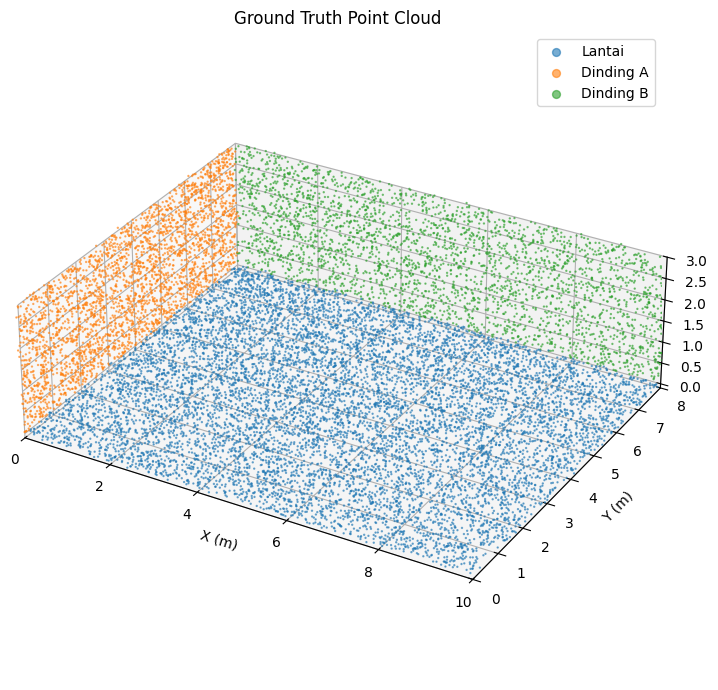

In [18]:
# Visualisasi Ground Truth
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for label in [0, 1, 2]:
    mask = labels_gt == label
    ax.scatter(
        points[mask, 0], points[mask, 1], points[mask, 2],
        c=LABEL_COLORS[label], s=0.5, label=LABEL_NAMES[label], alpha=0.6
    )

ax.set_xlim(0, L)
ax.set_ylim(0, W)
ax.set_zlim(-0.1, H)
ax.set_box_aspect([L, W, H])
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Ground Truth Point Cloud')
ax.legend(markerscale=8)
plt.tight_layout()
plt.show()

## 2. Metode 1: RANSAC Iteratif

**Model bidang**: ax + by + cz + d = 0

Algoritma per iterasi:
1. Pilih 3 titik secara acak → bentuk bidang
2. Hitung jarak semua titik ke bidang → hitung **inlier** (jarak < threshold)
3. Simpan model dengan inlier terbanyak

Dijalankan **3 kali** secara iteratif: setiap bidang yang ditemukan dihapus dari point cloud sebelum mencari bidang berikutnya.

In [19]:
def ransac_plane(pts, n_iter=1000, threshold=0.05):
    """Fit satu bidang ax+by+cz+d=0 ke pts, kembalikan (plane, inlier_indices)."""
    best_inliers = np.array([], dtype=int)
    best_plane = None
    n = len(pts)

    for _ in range(n_iter):
        idx = np.random.choice(n, 3, replace=False)
        p1, p2, p3 = pts[idx]

        normal = np.cross(p2 - p1, p3 - p1)
        norm = np.linalg.norm(normal)
        if norm < 1e-10:
            continue
        normal = normal / norm
        d = -np.dot(normal, p1)

        distances = np.abs(pts @ normal + d)
        inliers = np.where(distances < threshold)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_plane = (*normal, d)

    return best_plane, best_inliers


def assign_label(plane):
    """Tentukan label (0=lantai, 1=dinding A, 2=dinding B) dari normal bidang."""
    a, b, c, _ = plane
    dominant = np.argmax(np.abs([a, b, c]))
    return int(dominant == 2) * 0 + int(dominant == 0) * 1 + int(dominant == 1) * 2


# --- Jalankan RANSAC Iteratif ---
t0 = time.perf_counter()

labels_ransac = np.full(len(points), -1, dtype=int)
remaining = np.arange(len(points))

for _ in range(3):
    plane, local_inliers = ransac_plane(points[remaining], n_iter=1000, threshold=0.05)
    global_inliers = remaining[local_inliers]
    label = assign_label(plane)
    labels_ransac[global_inliers] = label
    remaining = np.setdiff1d(remaining, global_inliers)

t_ransac = time.perf_counter() - t0

print(f"Waktu RANSAC    : {t_ransac:.3f} detik")
print(f"Unclassified    : {np.sum(labels_ransac == -1)}")
for lbl, name in LABEL_NAMES.items():
    if lbl == -1: continue
    print(f"  {name:12s}: {np.sum(labels_ransac == lbl)} titik")

Waktu RANSAC    : 0.870 detik
Unclassified    : 1510
  Lantai      : 9162 titik
  Dinding A   : 2640 titik
  Dinding B   : 2688 titik


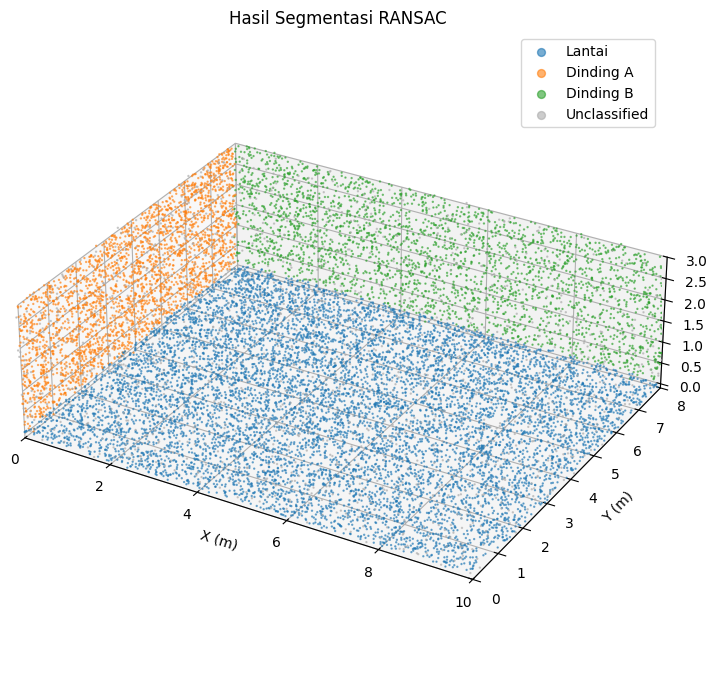

In [20]:
# Visualisasi hasil RANSAC
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for label in [0, 1, 2, -1]:
    mask = labels_ransac == label
    if not np.any(mask):
        continue
    ax.scatter(
        points[mask, 0], points[mask, 1], points[mask, 2],
        c=LABEL_COLORS[label], s=0.5, label=LABEL_NAMES[label], alpha=0.6
    )

ax.set_xlim(0, L)
ax.set_ylim(0, W)
ax.set_zlim(-0.1, H)
ax.set_box_aspect([L, W, H])
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Hasil Segmentasi RANSAC')
ax.legend(markerscale=8)
plt.tight_layout()
plt.show()

=== Evaluasi RANSAC ===
Akurasi  : 0.9912
Precision: 0.9932
Recall   : 0.9852
F1-Score : 0.9892

              precision    recall  f1-score   support

      Lantai       0.99      1.00      0.99      9069
   Dinding A       1.00      0.98      0.99      2699
   Dinding B       0.99      0.98      0.99      2722

    accuracy                           0.99     14490
   macro avg       0.99      0.99      0.99     14490
weighted avg       0.99      0.99      0.99     14490



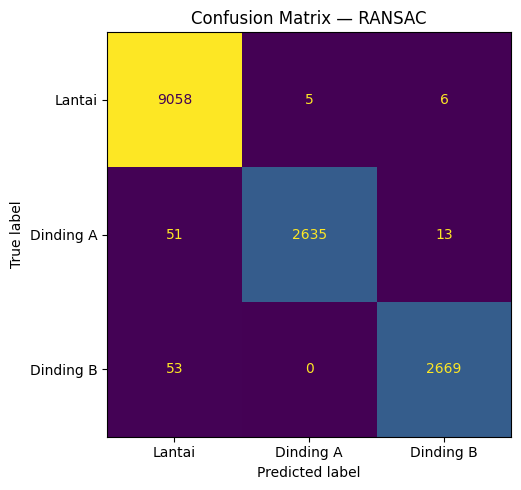

In [21]:
# Evaluasi RANSAC
mask_valid = labels_ransac != -1
y_true = labels_gt[mask_valid]
y_pred = labels_ransac[mask_valid]

print("=== Evaluasi RANSAC ===")
print(f"Akurasi  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=[LABEL_NAMES[i] for i in range(3)], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(cm, display_labels=[LABEL_NAMES[i] for i in range(3)])
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — RANSAC')
plt.tight_layout()
plt.show()

## 3. Metode 2: Region Growing

Algoritma:
1. Estimasi normal permukaan tiap titik menggunakan PCA pada tetangga terdekat (KNN)
2. Pilih seed point yang belum dikunjungi
3. Tumbuhkan region: tambahkan tetangga yang sudut normalnya < threshold ke antrian
4. Ulangi hingga semua titik terkunjungi
5. Ambil 3 region terbesar → tentukan label dari komponen normal dominan

In [22]:
from collections import deque

def compute_normals(pts, radius=0.5, max_nn=30):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=radius, max_nn=max_nn)
    )
    return np.asarray(pcd.normals), pcd


def region_growing(pts, normals, pcd, k=20, angle_thresh=15.0, min_pts=200):
    n = len(pts)
    visited = np.zeros(n, dtype=bool)
    kdtree = o3d.geometry.KDTreeFlann(pcd)
    regions = []

    for seed in range(n):
        if visited[seed]:
            continue
        region = []
        queue = deque([seed])
        visited[seed] = True
        ref_normal = normals[seed].copy()

        while queue:
            curr = queue.popleft()
            region.append(curr)
            _, neighbors, _ = kdtree.search_knn_vector_3d(pts[curr], k)
            for nb in neighbors[1:]:
                if visited[nb]:
                    continue
                cos_a = abs(float(np.dot(normals[nb], ref_normal)))
                if cos_a >= np.cos(np.radians(angle_thresh)):
                    visited[nb] = True
                    queue.append(nb)

        if len(region) >= min_pts:
            regions.append(np.array(region))

    return regions


def assign_label_from_normal(idx, normals):
    avg = np.mean(normals[idx], axis=0)
    dominant = int(np.argmax(np.abs(avg)))
    return {2: 0, 0: 1, 1: 2}[dominant]


# --- Jalankan Region Growing ---
t0 = time.perf_counter()

normals, pcd_rg = compute_normals(points)
regions = region_growing(points, normals, pcd_rg, k=20, angle_thresh=15.0, min_pts=200)

labels_rg = np.full(len(points), -1, dtype=int)
regions_top3 = sorted(regions, key=len, reverse=True)[:3]
for region in regions_top3:
    label = assign_label_from_normal(region, normals)
    labels_rg[region] = label

t_rg = time.perf_counter() - t0

print(f"Waktu Region Growing : {t_rg:.3f} detik")
print(f"Jumlah region ditemukan: {len(regions)}")
print(f"Unclassified         : {np.sum(labels_rg == -1)}")
for lbl, name in LABEL_NAMES.items():
    if lbl == -1: continue
    print(f"  {name:12s}: {np.sum(labels_rg == lbl)} titik")

Waktu Region Growing : 0.511 detik
Jumlah region ditemukan: 3
Unclassified         : 735
  Lantai      : 9684 titik
  Dinding A   : 2795 titik
  Dinding B   : 2786 titik


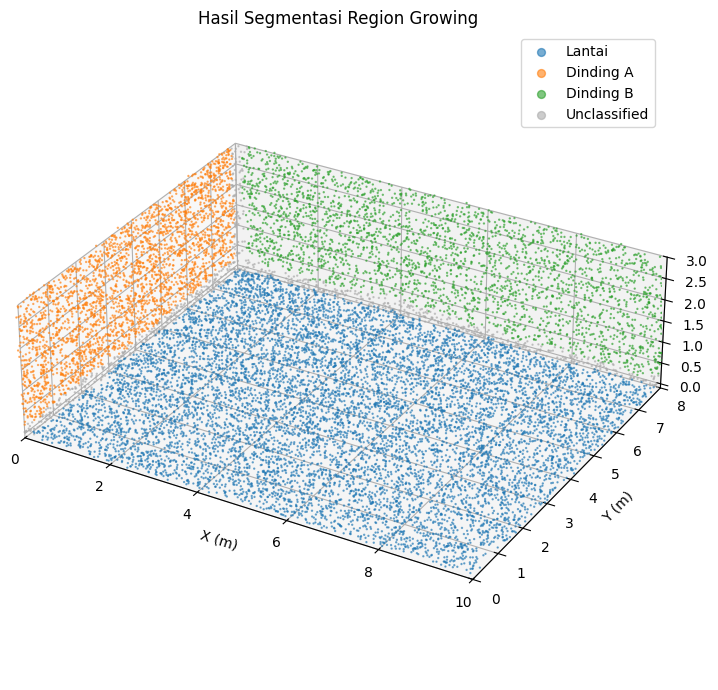

In [23]:
# Visualisasi hasil Region Growing
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for label in [0, 1, 2, -1]:
    mask = labels_rg == label
    if not np.any(mask):
        continue
    ax.scatter(
        points[mask, 0], points[mask, 1], points[mask, 2],
        c=LABEL_COLORS[label], s=0.5, label=LABEL_NAMES[label], alpha=0.6
    )

ax.set_xlim(0, L)
ax.set_ylim(0, W)
ax.set_zlim(-0.1, H)
ax.set_box_aspect([L, W, H])
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Hasil Segmentasi Region Growing')
ax.legend(markerscale=8)
plt.tight_layout()
plt.show()

=== Evaluasi Region Growing ===
Akurasi  : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

              precision    recall  f1-score   support

      Lantai       1.00      1.00      1.00      9684
   Dinding A       1.00      1.00      1.00      2795
   Dinding B       1.00      1.00      1.00      2786

    accuracy                           1.00     15265
   macro avg       1.00      1.00      1.00     15265
weighted avg       1.00      1.00      1.00     15265



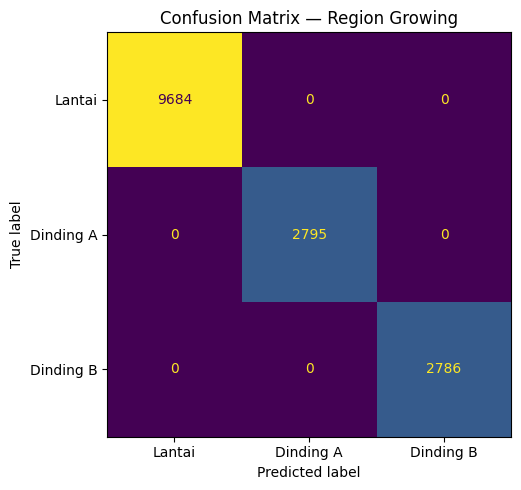

In [24]:
# Evaluasi Region Growing
mask_valid = labels_rg != -1
y_true = labels_gt[mask_valid]
y_pred = labels_rg[mask_valid]

print("=== Evaluasi Region Growing ===")
print(f"Akurasi  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=[LABEL_NAMES[i] for i in range(3)], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(cm, display_labels=[LABEL_NAMES[i] for i in range(3)])
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Region Growing')
plt.tight_layout()
plt.show()

## 4. Perbandingan Metode

Membandingkan performa RANSAC vs Region Growing berdasarkan metrik klasifikasi dan waktu komputasi.

In [ ]:
# Hitung metrik kedua metode
def compute_metrics(labels_pred, labels_true):
    mask = labels_pred != -1
    y_t, y_p = labels_true[mask], labels_pred[mask]
    return {
        'Akurasi'  : accuracy_score(y_t, y_p),
        'Precision': precision_score(y_t, y_p, average='macro', zero_division=0),
        'Recall'   : recall_score(y_t, y_p, average='macro', zero_division=0),
        'F1-Score' : f1_score(y_t, y_p, average='macro', zero_division=0),
    }

metrics_ransac = compute_metrics(labels_ransac, labels_gt)
metrics_rg     = compute_metrics(labels_rg, labels_gt)

# Tabel perbandingan
print(f"{'Metrik':<12} {'RANSAC':>10} {'Region Growing':>16}")
print('-' * 40)
for m in ['Akurasi', 'Precision', 'Recall', 'F1-Score']:
    print(f"{m:<12} {metrics_ransac[m]:>10.4f} {metrics_rg[m]:>16.4f}")
print('-' * 40)
print(f"{'Waktu (s)':<12} {t_ransac:>10.3f} {t_rg:>16.3f}")
unclass_ransac = int(np.sum(labels_ransac == -1))
unclass_rg     = int(np.sum(labels_rg == -1))
print(f"{'Unclassified':<12} {unclass_ransac:>10} {unclass_rg:>16}")

In [ ]:
# Visualisasi perbandingan metrik + waktu
metrik_names = ['Akurasi', 'Precision', 'Recall', 'F1-Score']
vals_ransac = [metrics_ransac[m] for m in metrik_names]
vals_rg     = [metrics_rg[m]     for m in metrik_names]

x = np.arange(len(metrik_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Bar chart metrik ---
ax = axes[0]
bars1 = ax.bar(x - w/2, vals_ransac, w, label='RANSAC',         color='#1f77b4')
bars2 = ax.bar(x + w/2, vals_rg,     w, label='Region Growing', color='#ff7f0e')
ax.set_xticks(x)
ax.set_xticklabels(metrik_names)
ax.set_ylim(0.95, 1.01)
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Metrik Klasifikasi')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

# --- Bar chart waktu ---
ax2 = axes[1]
metode = ['RANSAC', 'Region Growing']
waktu  = [t_ransac, t_rg]
colors = ['#1f77b4', '#ff7f0e']
bars = ax2.bar(metode, waktu, color=colors, width=0.4)
ax2.set_ylabel('Waktu (detik)')
ax2.set_title('Perbandingan Waktu Komputasi')
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}s', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()